## EXP-12 :  Face Detection with Haar Cascades
## NAME : HARISH S
## REG NO: 212224040105

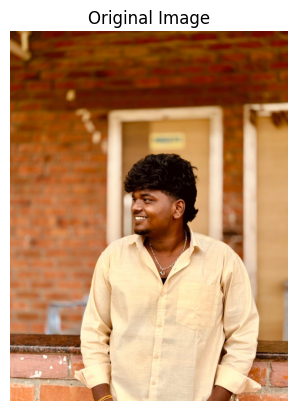

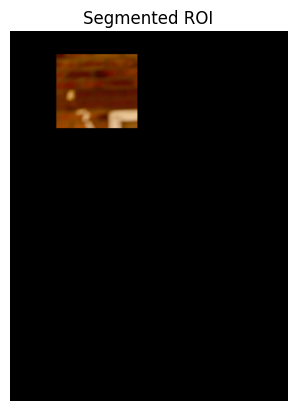

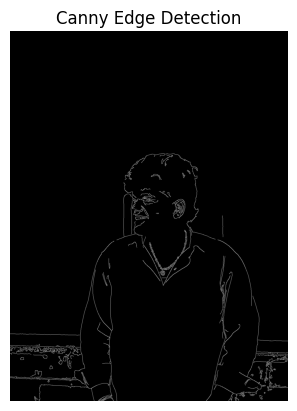

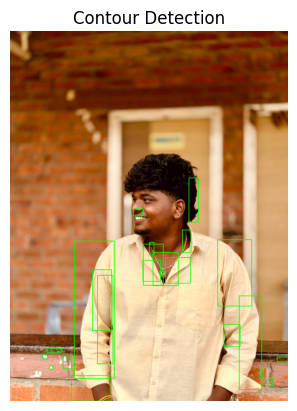

⚠️ Model files not found → Skipping Object Detection part


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# =========================
# PART 1: ROI SEGMENTATION
# =========================

image = cv2.imread('Hari.jpeg')

if image is None:
    print("Error: Hari.jpeg not found")
    exit()

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')
plt.show()

# ROI
roi = image[100:420, 200:550]

mask = np.zeros_like(image)
mask[100:420, 200:550] = roi

segmented = cv2.bitwise_and(image, mask)

plt.imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))
plt.title("Segmented ROI")
plt.axis('off')
plt.show()


# =========================
# PART 2: EDGE DETECTION
# =========================

image = cv2.imread('Hari.jpeg')

if image is None:
    print("Error: Hari.jpeg not found")
    exit()

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blur, 50, 150)

plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')
plt.show()

contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

result = image.copy()

for c in contours:
    if cv2.contourArea(c) > 50:
        x, y, w, h = cv2.boundingRect(c)
        cv2.rectangle(result, (x, y), (x+w, y+h), (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Contour Detection")
plt.axis('off')
plt.show()


# =========================
# PART 3: OBJECT DETECTION (SAFE VERSION)
# =========================

config_file = 'deploy.prototxt'
weights_file = 'mobilenet_iter_73000.caffemodel'

# If model files NOT found → skip safely
if not os.path.exists(config_file) or not os.path.exists(weights_file):
    print("⚠️ Model files not found → Skipping Object Detection part")
else:
    net = cv2.dnn.readNetFromCaffe(config_file, weights_file)

    class_labels = {
        0:'background',1:'aeroplane',2:'bicycle',3:'bird',4:'boat',
        5:'bottle',6:'bus',7:'car',8:'cat',9:'chair',10:'cow',
        11:'diningtable',12:'dog',13:'horse',14:'motorbike',
        15:'person',16:'pottedplant',17:'sheep',18:'sofa',
        19:'train',20:'tvmonitor'
    }

    image = cv2.imread('Hari.jpeg')

    if image is None:
        print("Error: itac.jpeg not found")
        exit()

    (h, w) = image.shape[:2]

    blob = cv2.dnn.blobFromImage(image, 0.007843, (300, 300), 127.5)
    net.setInput(blob)
    detections = net.forward()

    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]

        if confidence > 0.5:
            idx = int(detections[0, 0, i, 1])
            label = class_labels.get(idx, "Unknown")

            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype("int")

            cv2.rectangle(image, (startX, startY), (endX, endY), (0, 255, 0), 2)
            cv2.putText(image, label, (startX, startY - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Object Detection (MobileNet-SSD)")
    plt.axis('off')
    plt.show()